January 7th notes - sampling

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#01_materials/notebooks/dataset/listings.csv
# Load the Airbnb listings dataset from a CSV file
airbnb = pd.read_csv("01_materials/notebooks/dataset/listings.csv")

In [4]:
# Calculate and return the average price from the "price" column in the Airbnb dataset
airbnb["price"].mean()

np.float64(249.16526273565984)

In [5]:
# Set the random seed to 100 for reproducibility
np.random.seed(100)

# Randomly select a sample of 40 rows from the Airbnb dataset and calculate the average price from the "price" column
airbnb.sample(n=40)["price"].mean()

np.float64(222.875)

In [6]:

# Since no random seed is set, running this multiple times will result in different mean values.
airbnb.sample(n=40)["price"].mean()

np.float64(315.25)

In [8]:
# Initialize an empty list to store the samples
sample_list = []

# Take 20,000 samples, each with 40 listings, and label them by replicate number
for i in range(20_000):
    sample = airbnb.sample(40)           # Randomly sample 40 listings
    sample = sample.assign(replicate=i)  # Add a column to track the replicate number
    sample_list.append(sample)           # Append the sample to the list

# Combine all samples into one large DataFrame
samples = pd.concat(sample_list)

# Display the combined DataFrame
# samples

In [9]:

sample_estimates = (
     samples
    .groupby("replicate")
    ["price"]
    .mean()
    .reset_index(name="sample_mean")
)

# sample_estimates

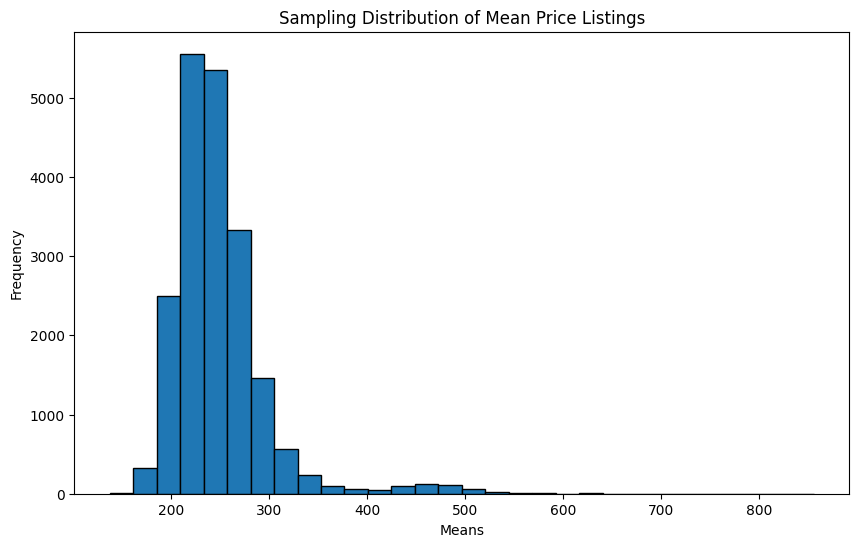

In [10]:

# Plot the histogram of the sampling distribution
plt.figure(figsize=(10, 6))
plt.hist(sample_estimates['sample_mean'], bins=30, edgecolor='black')


# Add titles and labels
plt.title('Sampling Distribution of Mean Price Listings')
plt.xlabel('Means')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [11]:
sample_estimates["sample_mean"].mean()

np.float64(248.71526)

In [13]:
np.random.seed(1234)
one_sample = airbnb.sample(n=40)
one_sample

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price
2912,5.970000e+17,Riley Park,Entire home/apt,9,3.0,4.0,5.0,214
787,1.986261e+07,Mount Pleasant,Entire home/apt,9,2.0,3.0,3.0,109
2696,5.333958e+07,Arbutus Ridge,Entire home/apt,3,1.0,1.0,0.0,200
3017,6.310000e+17,West End,Entire home/apt,2,1.0,1.0,0.0,223
1226,2.745958e+07,Downtown,Entire home/apt,1,NaN,1.0,NaN,126
2620,5.255417e+07,Downtown Eastside,Entire home/apt,4,1.0,1.0,2.0,198
4883,9.790000e+17,Downtown Eastside,Entire home/apt,7,2.0,3.0,4.0,834
608,1.554257e+07,Kitsilano,Entire home/apt,5,1.0,2.0,3.0,99
1400,3.124019e+07,Arbutus Ridge,Private room,2,1.0,1.0,2.0,133
149,3.100878e+06,Downtown,Entire home/apt,2,1.0,1.0,0.0,60


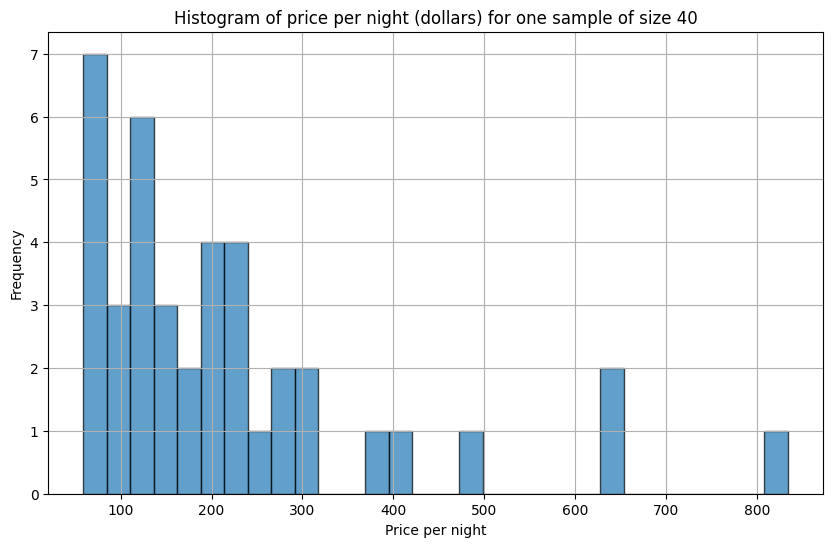

In [14]:
# Histogram of price per night (dollars) for one sample of size 40.
plt.figure(figsize=(10, 6))
plt.hist(one_sample['price'], bins=30, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Histogram of price per night (dollars) for one sample of size 40')
plt.xlabel('Price per night')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [15]:
boot1 = one_sample.sample(frac=1, replace=True)

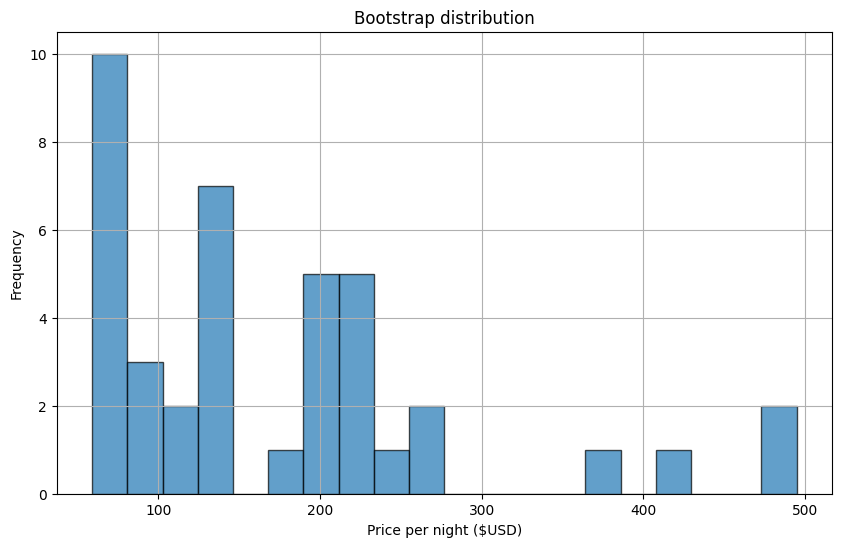

In [16]:
# Plot the histogram of the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(boot1['price'], bins=20, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Bootstrap distribution')
plt.xlabel('Price per night ($USD)')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [17]:
bootstrap_samples = [] # initialize an empty list

# Create a for loop
for i in range(20000):
    sample = one_sample.sample(frac=1, replace=True)
    sample = sample.assign(replicate = i)
    bootstrap_samples.append(sample)

In [18]:
boot20000 = pd.concat(bootstrap_samples)
bootstrap_samples

[                id             neighbourhood        room_type  accommodates  \
 2480  5.073003e+07                  Oakridge  Entire home/apt             3   
 4419  9.120000e+17                  Downtown  Entire home/apt             4   
 273   6.315732e+06                  Fairview  Entire home/apt             3   
 548   1.455531e+07        Grandview-Woodland  Entire home/apt             2   
 3795  8.020000e+17                Riley Park  Entire home/apt             4   
 1594  3.490318e+07                  West End  Entire home/apt             6   
 4775  9.650000e+17          Hastings-Sunrise  Entire home/apt             4   
 3851  8.160000e+17          Hastings-Sunrise  Entire home/apt             4   
 3076  6.440000e+17  Kensington-Cedar Cottage  Entire home/apt             2   
 310   7.183413e+06        Grandview-Woodland     Private room             2   
 3017  6.310000e+17                  West End  Entire home/apt             2   
 310   7.183413e+06        Grandview-Woo

In [19]:
boot_means = boot20000.groupby("replicate")["price"].mean().reset_index(name = "mean_price")

In [20]:
boot_means

,replicate,mean_price
0,0,208.250
1,1,205.800
2,2,183.925
3,3,211.600
4,4,239.475
...,...,...
19995,19995,176.725
19996,19996,217.450
19997,19997,204.600
19998,19998,216.900


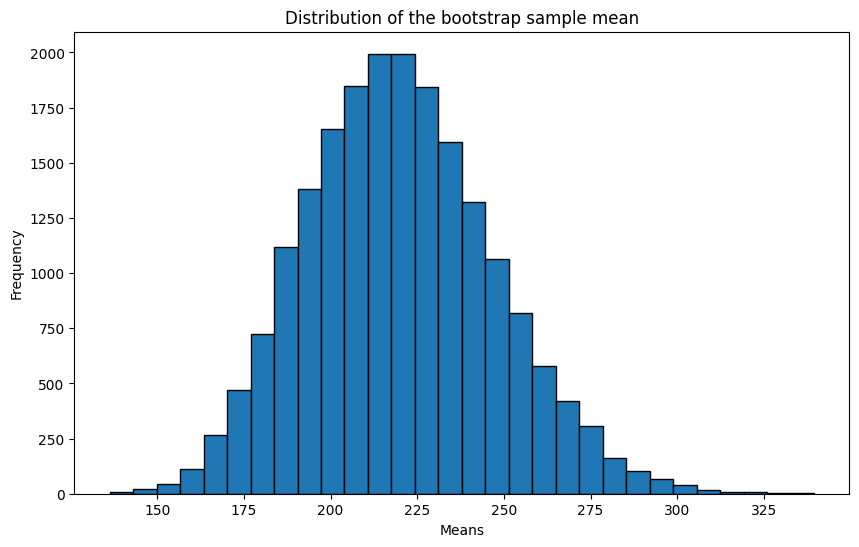

In [21]:
# Plot the histogram of the sampling distribution
plt.figure(figsize=(10, 6))
plt.hist(boot_means['mean_price'], bins=30, edgecolor='black')

# Add titles and labels
plt.title('Distribution of the bootstrap sample mean')
plt.xlabel('Means')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [22]:
# Confidence interval
boot_means["mean_price"].quantile([0.025,0.975])

0.025    171.248750
0.975    276.300625
Name: mean_price, dtype: float64